<div style='background-image: url("../../share/images/header.svg") ; padding: 0px ; background-size: cover ; border-radius: 5px ; height: 250px'>
    <div style="float: right ; margin: 50px ; padding: 20px ; background: rgba(255 , 255 , 255 , 0.7) ; width: 50% ; height: 150px">
        <div style="position: relative ; top: 50% ; transform: translatey(-50%)">
            <div style="font-size: xx-large ; font-weight: 900 ; color: rgba(0 , 0 , 0 , 0.8) ; line-height: 100%">Computational Seismology</div>
            <div style="font-size: large ; padding-top: 20px ; color: rgba(0 , 0 , 0 , 0.5)"> SBP-SAT finite difference method for the 2D elastic wave equation in velocity-stress form </div>
        </div>
    </div>
</div>


---

This notebook is based on the paper [Dynamic earthquake rupture simulations on nonplanar faults embedded in 3D geometrically complex, heterogeneous Earth models](https://pangea.stanford.edu/~edunham/publications/Duru_Dunham_FD3d_JCP16.pdf)


##### Authors:
* Kenneth Duru

**** Exercises****



In [1]:
# Parameters initialization and plotting the simulation
# Import necessary routines
%matplotlib notebook
import numpy as np
import matplotlib.pyplot as plt
import RK4_2D

#plt.switch_backend("TkAgg")          # plots in external window
plt.switch_backend("nbagg")           # plots within this notebook

<IPython.core.display.Javascript object>


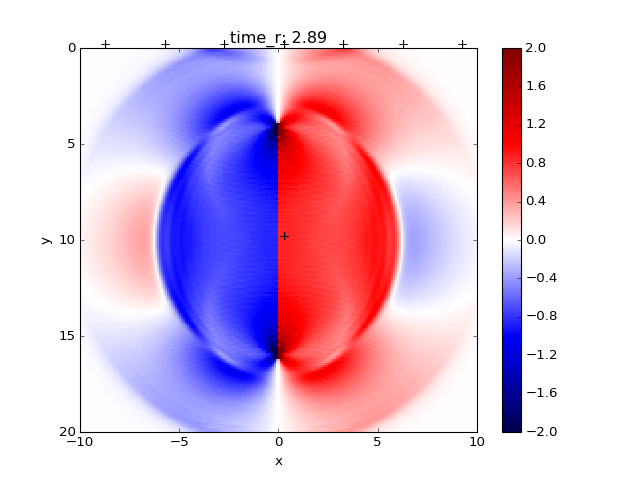

[ 9 39 69 99 99]
[  0   0   0   0 100]


<IPython.core.display.Javascript object>


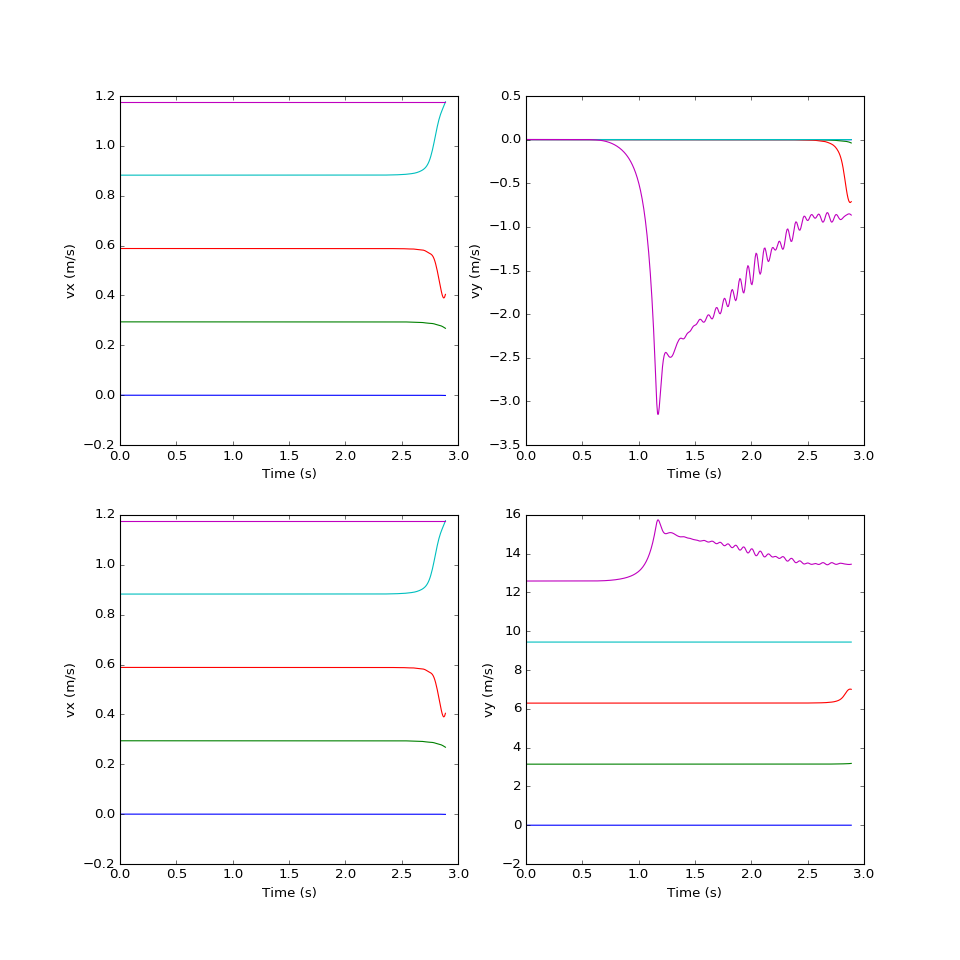

In [2]:

Lx = 10.0     # length of the domain (x-axis)
Ly = 20.0     # width of the domain (y-axis)

nx = 100       # grid points in x
ny = 200       # grid points in y
nt = 401       # number of time steps
CFL = 0.5


dx = Lx/nx    # spatial step in x
dy = Ly/ny    # spatial step in y

isnap = 5     # snapshot frequency

nf = 5        # number of fields
cs = 3.464    # shear wave speed
cp = 6.0      # compresional wave speed
rho = 2.6702  # density

# source parameters
x0 = -15.0        # [km]
y0 = 7.5         # [km]
t0 = 0.0         # [s]
T =  0.1         # [s]
M0 = 00.0      # [MPa]

source_type = 'Gaussian' # 'Gaussian', 'Brune'

fric_law = 'RS'   #RS OR SW


# RS - add correct parameters

M = [0, 0, 1., 1., 0]

source_parameter = [x0, y0, t0, T, M0, source_type, M]

# extract Lame parameters
mu = rho*cs**2
Lambda = rho*cp**2-2.0*mu

dt = CFL/np.sqrt(cp**2 + cs**2)*dx    # Time step

order = 6        # spatial order of accuracy

# Model type, available are "homogeneous", "fault_zone",
# "surface_low_velocity_zone", "random", "topography",
# "slab"
model_type = "homogeneous"

# Initialize velocity model
Mat_l = np.zeros((nx, ny, 3))

Mat_r = np.zeros((nx, ny, 3))

if model_type == "homogeneous":
    Mat_l[:,:,0] += rho
    Mat_l[:,:,1] += Lambda
    Mat_l[:,:,2] += mu
    
    Mat_r[:,:,0] += rho
    Mat_r[:,:,1] += Lambda
    Mat_r[:,:,2] += mu

elif model_type == "random":
    pert_l = 0.4
    r_rho_l = 2.0 * (np.random.rand(nx, ny) - 0.5) * pert_l
    r_mu_l = 2.0 * (np.random.rand(nx, ny) - 0.5) * pert_l
    r_lambda_l = 2.0 * (np.random.rand(nx, ny) - 0.5) * pert_l    
    Mat_l[:,:,0] += rho*(1.0 + r_rho_l)
    Mat_l[:,:,1] += Lambda*(1.0 + r_lambda_l)
    Mat_l[:,:,2] += mu*(1.0 + r_mu_l)
    
    pert_r = 0.4
    r_rho_r = 2.0 * (np.random.rand(nx, ny) - 0.5) * pert_r
    r_mu_r = 2.0 * (np.random.rand(nx, ny) - 0.5) * pert_r
    r_rambda_r = 2.0 * (np.random.rand(nx, ny) - 0.5) * pert_r
    Mat_r[:,:,0] += rho*(1.0 + r_rho_r)
    Mat_r[:,:,1] += Lambda*(1.0 + r_rambda_r)
    Mat_r[:,:,2] += mu*(1.0 + r_mu_r)
    
# Initialize pressure at different time steps and the second
# derivatives in each direction
F_l = np.zeros((nx, ny, nf))
Fnew_l = np.zeros((nx, ny, nf))
X_l = np.zeros((nx, ny))
Y_l = np.zeros((nx, ny))
p_l = np.zeros((nx, ny))

F_r = np.zeros((nx, ny, nf))
Fnew_r = np.zeros((nx, ny, nf))
X_r = np.zeros((nx, ny))
Y_r = np.zeros((nx, ny))
p_r = np.zeros((nx, ny))




for i in range(0, nx):
    for j in range(0, ny):
        X_l[i,j] = -Lx + i*dx
        Y_l[i,j] = j*dy
        
        X_r[i,j] = i*dx
        Y_r[i,j] = j*dy
        
        #F_l[i,j,1] = -10**-12 
        #F_r[i,j,1] =  10**-12
        

Y_fault =np.zeros((ny, 1)) 
Y0 = 10

for j in range(0, ny):
        #Y_fault[j, 0] = j*dy
        
        if np.abs(j*dy-Y0) <= 1.5:
            Y_fault[j, 0] = 1.0

# FRICTION PARAMETERS

# Calculations and plottings for on fault slip velocity and stress


slip = np.zeros((ny, 1))
psi = np.zeros((ny, 1))
FaultOutput = np.zeros((ny, nt, 6)) # c
FaultOutput0 = np.zeros((ny, 6))

if fric_law not in ('SW', 'RS'):
    # Choose friction law: fric_law
    # We use linear (LN: T = alpha*v, alpha >=0)
    # Slip-weakening (SW)
    # Rate-and-state friction law (RS)
    
     print('friction law not implemented. choose fric_law = SW or fric_law = RS')
     exit(-1)
    
if fric_law  in ('SW'):
     alpha = np.ones((ny, 1))*1e1000000                      # initial friction coefficient
     slip = np.zeros((ny, 1))                        # initial slip (in m)
     slip_new = np.zeros((ny, 1))
     #Tau_0 = np.ones((ny, 1))*(70+11.6*(np.exp(-(Y_fault-7.0)**2/(2*9))))               # initial load (81.24 in MPa), slight increase will unlock the fault
     Tau_0 = np.ones((ny, 1))*(70+11.6*Y_fault)   
     alp_s = np.ones((ny, 1))*0.677                          # stastic friction
     alp_d = np.ones((ny, 1))*0.525                          # dynamic friction
     D_c = np.ones((ny, 1))*0.4                              # critical slip
     sigma_n = -np.ones((ny, 1))*120.0                        # normal stress 
     
        
     # These are not needed for the slip weakening case   
     psi = np.ones((ny, 1))*0.0                         # initial condition for the state variable in friction law
     psi_new = np.ones((ny, 1))*0.0
     L0 = np.ones((ny, 1))*1.0                               # state evolution distance
     f0 = np.ones((ny, 1))*1.0                               # referance friction coeff
     a = np.ones((ny, 1))*1.0                                # direct effect 
     b = np.ones((ny, 1))*1.0                                # evolution parameter 
     V0 = np.ones((ny, 1))*1.0                               # reference slip rate
        
     FaultOutput[:, 0, 2] = sigma_n[:,0]   
     FaultOutput[:, 0, 3] = Tau_0[:,0] 
     FaultOutput[:, 0, 4] = slip[:,0] 
     FaultOutput[:, 0, 5] = psi[:,0]   
    
if fric_law  in ('RS'):
     alpha = np.ones((ny, 1))*1e1000000                      # initial friction coefficient                                                                                   
     slip = np.ones((ny, 1))*0.0                         # initial slip (in m) 
     slip_new = np.zeros((ny, 1))
     #Tau_0 = np.ones((ny, 1))*81.24+0.1*0.36                 # initial load (81.24 in MPa), slight increase will unlock the fault   
     psi = np.ones((ny, 1))*0.4367                      # initial condition for the state variable in friction law
     psi_new = np.ones((ny, 1))*0.0
     L0 = np.ones((ny, 1))*0.02                              # state evolution distance
     f0 = np.ones((ny, 1))*0.6                               # referance friction coeff
     a = np.ones((ny, 1))*0.008                              # direct effect 
     b = np.ones((ny, 1))*0.012                              # evolution parameter 
     V0 = np.ones((ny, 1))*1.0e-6                            # reference slip rate
     sigma_n = -np.ones((ny, 1))*120.0                        # background normal stress 
     Tau_0 = np.ones((ny, 1))*75 #-2*0.2429*sigma_n*Y_fault
     Vin = np.ones((ny, 1))*2.0e-12 
     theta = L0/V0*np.exp(((a*np.log(2.0*np.sinh(75/(a*120)))-f0-a*np.log(Vin/V0))/b))
     psi[:,0] = f0[:,0] + b[:,0]*np.log(V0[:,0]/L0[:,0]*theta[:,0])
                          
    
        
        

     # These are not needed for the rate and state case   
     alp_s = np.ones((ny, 1))*1.0                             # stastic friction
     alp_d = np.ones((ny, 1))*1.0                             # dynamic friction
     D_c = np.ones((ny, 1))*1.0                               # critical slip
        
     FaultOutput[:, 0, 2] = sigma_n[:,0]  
     FaultOutput[:, 0, 3] = Tau_0[:,0]
     FaultOutput[:, 0, 4] = slip[:,0]
     FaultOutput[:, 0, 5] = psi[:,0] 
        
friction_parameters = np.zeros((12, ny))    
#friction_parameters = [alpha, alpha, Tau_0, L0, f0, a, b, V0, sigma_n, alp_s, alp_d, D_c]    
#                        0         1      2     3   4  5  6   7    8       9      10  11

for j in range(0, ny):
        friction_parameters[0, j] = alpha[j, 0]
        friction_parameters[1, j] = alpha[j, 0]
        friction_parameters[2, j] = Tau_0[j, 0]
        friction_parameters[3, j] = L0[j, 0]
        friction_parameters[4, j] = f0[j, 0]
        friction_parameters[5, j] = a[j, 0]
        
        
        friction_parameters[6, j] = b[j, 0]
        friction_parameters[7, j] = V0[j, 0]
        friction_parameters[8, j] = sigma_n[j, 0]
        friction_parameters[9, j] = alp_s[j, 0]
        friction_parameters[10, j] = alp_d[j, 0]
        friction_parameters[11, j] = D_c[j, 0]
        
        #if np.abs(j*dy-Y0) <= 1.5:
        #    Y_fault[j, 0] = 1.0
            
############ END FRICTION PARAMETERS


v = 2.0

#p_l = np.sqrt(F_l[:,:,0]**2 + F_l[:,:,1]**2)
#p_r = np.sqrt(F_r[:,:,0]**2 + F_r[:,:,1]**2)

p_l = F_l[:,:,1]
p_r = F_r[:,:,1]

image_l = plt.imshow(p_l.transpose(), aspect='auto',extent=[-Lx, 0, Ly,0]
          ,cmap = 'seismic', vmin=-v, vmax=+v, animated=True, 
          interpolation='none')

image_r = plt.imshow(np.squeeze(np.append([p_l.transpose()],[p_r.transpose()],axis=2)), aspect='auto',extent=[-Lx,Lx,Ly,0]
          ,cmap = 'seismic', vmin=-v, vmax=+v, animated=True, 
          interpolation='none')

# Receiver locations left
rx_l = np.array([-9, -6, -3, 0, 0])
ry_l = np.array([0, 0, 0, 0, 10])

irx_l = np.array([1, 1, 0, 1, 1])
iry_l = np.array([0, 0, 31, 0, 0])

for i in range(len(rx_l)):
    irx_l[i] = (np.ceil(rx_l[i]/dx))+(nx-1)
    iry_l[i] = (np.ceil(ry_l[i]/dy))

seisvx_l = np.zeros((len(irx_l), nt))
seisvy_l = np.zeros((len(irx_l), nt))

# Receiver locations right

rx_r = np.array([9, 6, 3, 0, 0])
ry_r = np.array([0, 0, 0, 0, 10])

irx_r = np.array([1, 1, 1, 1, 1])
iry_r = np.array([0, 0, 0, 0, 0])

for i in range(len(rx_r)):
    irx_r[i] = (np.ceil(rx_r[i]/dx))
    iry_r[i] = (np.ceil(ry_r[i]/dy))

seisvx_r = np.zeros((len(irx_r), nt))
seisvy_r = np.zeros((len(irx_r), nt))



# Plot the receivers
for x, y in zip(rx_l, ry_l):
    plt.text(x, y, '+')
    
for x, y in zip(rx_r, ry_r):
    plt.text(x, y, '+')

plt.text(x0, y0, 'o')
plt.colorbar()
plt.xlabel('x')
plt.ylabel('y')

plt.show()
# Boundary reflection coefficients: 0<= r[j] <= 1
r_l = np.array([0.,0.,1.,0.])
r_r = np.array([0.,0.,1.,0.])

# required for seismograms
ir_l = np.arange(len(irx_l))
ir_r = np.arange(len(irx_r))


print(irx_l)
print(iry_l)

#exit()



#################################################

# Time-stepping 
for it in range(nt):
    
    t = it*dt
    #4th order Runge-Kutta 
    RK4_2D.elastic_RK4_2D(Fnew_l, F_l, Mat_l, X_l, Y_l, t, nf, nx, ny, dx, dy, dt, order, r_l, source_parameter, Fnew_r, F_r, Mat_r, X_r, Y_r, r_r, friction_parameters, slip,  psi, slip_new, psi_new, fric_law, FaultOutput0, Y0)

    
    # update fields
    F_l = Fnew_l
    F_r = Fnew_r
    slip = slip_new 
    psi = psi_new
    
    FaultOutput[:, it, :] = FaultOutput0

    
    #extract particle velocity for visualization
    #p_l = np.sqrt(F_l[:,:,0]**2 + F_l[:,:,1]**2)
    #p_r = np.sqrt(F_r[:,:,0]**2 + F_r[:,:,1]**2)
    
    
    p_l = F_l[:,:,1]
    p_r = F_r[:,:,1]
    
    p_b = np.squeeze(np.append([p_l.transpose()],[p_r.transpose()],axis=2)) # p for both, transposed to plot
    
    # update time
    t = it*dt
    
    # Plot every isnap-th iteration
    if it % isnap == 0:                    # you can change the speed of the plot by increasing the plotting interval
        #plt.subplot(1,2,1)
        #plt.title("time_l: %.2f" % t)
        #image_l.set_data(p_l.transpose())
        #plt.gcf().canvas.draw()
        #plt.show()
        #print(it)
        
        #plt.subplot(1,2,2)
        plt.title("time_r: %.2f" % t)
        image_r.set_data(p_b)
        plt.gcf().canvas.draw()
        #plt.show()
        #print(it)

    
    # Save seismograms
    seisvx_l[ir_l, it] = F_l[irx_l[ir_l], iry_l[ir_l], 0]
    seisvy_l[ir_l, it] = F_l[irx_l[ir_l], iry_l[ir_l], 1]
    
    seisvx_r[ir_r, it] = F_r[irx_r[ir_r], iry_r[ir_r], 0]
    seisvy_r[ir_r, it] = F_r[irx_r[ir_r], iry_r[ir_r], 1]
    
plt.ioff()
plt.figure(figsize=(12, 12))

plt.subplot(2,2,1)
ymax = seisvx_l.ravel().max()
time = np.arange(nt) * dt
for ir_l in range(len(seisvx_l)):
    plt.plot(time, seisvx_l[ir_l, :] + ymax * ir_l)
    plt.xlabel('Time (s)')
    plt.ylabel('vx (m/s)')

plt.subplot(2,2,2)
ymax = seisvy_l.ravel().max()
for ir_l in range(len(seisvy_l)):
    plt.plot(time, seisvy_l[ir_l, :] + ymax * ir_l)
    plt.xlabel('Time (s)')
    plt.ylabel('vy (m/s)')


    
plt.subplot(2,2,3)
ymax = seisvx_r.ravel().max()
time = np.arange(nt) * dt
for ir_r in range(len(seisvx_r)):
    plt.plot(time, seisvx_r[ir_r, :] + ymax * ir_r)
    plt.xlabel('Time (s)')
    plt.ylabel('vx (m/s)')

plt.subplot(2,2,4)
ymax = seisvy_r.ravel().max()
for ir_r in range(len(seisvy_r)):
    plt.plot(time, seisvy_r[ir_r, :] + ymax * ir_r)
    plt.xlabel('Time (s)')
    plt.ylabel('vy (m/s)')
    
    
plt.show()




<IPython.core.display.Javascript object>


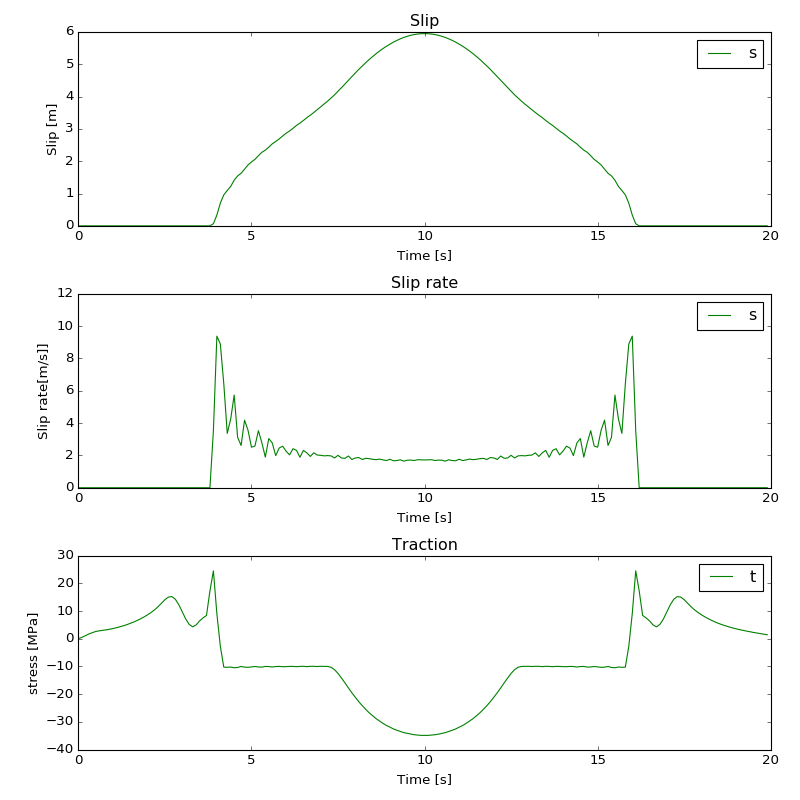

In [3]:
fig1 = plt.figure(figsize=(10,10))
ax3 = fig1.add_subplot(3,1,1)
line3 = ax3.plot(0,0,'g')
plt.title('Slip')
plt.xlabel('Time [s]')
plt.ylabel('Slip [m]')

ax4 = fig1.add_subplot(3,1,2)
line4 = ax4.plot(0,0,'g')
plt.title('Slip rate')
plt.xlabel('Time [s]')
plt.ylabel('Slip rate[m/s]]')

ax5 = fig1.add_subplot(3,1,3)
line5 = ax5.plot(0,0,'g')
plt.title('Traction')
plt.xlabel('Time [s]')
plt.ylabel('stress [MPa]')

plt.tight_layout()
plt.ion()
plt.show()

y_fault = Y_l[-1,:]

for it in range(nt):
    slip_ = FaultOutput[:, it, 4]
    sliprate_ = np.sqrt(FaultOutput[:, it, 0]**2 + FaultOutput[:, it, 1]**2)
    traction_ = FaultOutput[:, it, 3]
    if it % 1 == 0: 
        
        for l in line3:
            l.remove()
            del l               
        for l in line4:
            l.remove()
            del l
        for l in line5:
            l.remove()
            del l

        # Display lines
        line3 = ax3.plot(y_fault,slip_,'g')
        ax3.legend(iter(line3),('slip'))
        line4 = ax4.plot(y_fault,sliprate_,'g')
        ax4.legend(iter(line4),('slip rate'))
        line5 = ax5.plot(y_fault,traction_,'g')
        ax5.legend(iter(line5),('traction'))
        plt.gcf().canvas.draw()
                   
    
plt.ioff()
plt.show()
    

In [4]:
print(irx_l)
print(iry_l)

[ 9 39 69 99 99]
[  0   0   0   0 100]


In [5]:
print(irx_r)
print(iry_r)


[90 60 30  0  0]
[  0   0   0   0 100]


In [6]:
type(Tau_0)

numpy.ndarray

In [7]:
Tau_0.size

200

In [8]:
     Tau_0 = np.ones((ny, 1))*(70+1.0*1.24*np.transpose(np.exp(-(Y_fault-7.0)**2/(2*5))))                 # initial load (81.24 in MPa), slight increase will unlock the fault
